Zachary Griffin,    Data110,   4-1-26,  Zare

# Homework5: Exploration of Heart Disease Data (Use UCI Dataset)
## Part 1: Confidence Intervals for a Personalized Subgroup
    1. Define a subgroup of patients based on age, sex, chest pain type, or another variable of your choice.
    2. For this subgroup:
        - Randomly select three different sample sizes (e.g., small, medium, large).
        - Calculate the proportion of patients with heart disease.
        - Construct 95% confidence intervals.
    3. Questions:
        - How does interval width change with sample size?
        - Compare your subgroup’s proportion to the overall population.
        - Write 2–3 sentences explaining why your subgroup may differ from the population.
        
## Part 2: Hypothesis Tests 

### Choose two tests that were not done in class. For each:

    - State your research question and define your null and alternative hypotheses.
    - Select an appropriate test (two-proportion, one-sample t-test, two-sample t-test).
    - Compute the test and report the statistic and p-value.
    - Visualize the data appropriately (bar chart, histogram, or boxplot).
    - Write 2–3 sentences interpreting your results.
    
## Part 3: Type I and Type II Errors
### For one of your tests above, describe:
    - What a Type I error would mean in your context.
    - What a Type II error would mean.
    - Explain which error would be more critical for patient care or medical research.

## Part 4: Sample Size and Power Planning
    - Pick one of your tests.
    - Assume α = 0.05 and desired power between 0.8–0.9.
    - Estimate effect size from your data or justify a hypothetical one.
    - Compute the required sample size.
    - Optional: Generate a power curve showing power vs sample size for your chosen effect size.
    - Write 2–3 sentences interpreting how sample size, effect size, and power interact.

# Load Data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint, proportions_ztest, proportion_effectsize
from scipy import stats
from statsmodels.stats.power import NormalIndPower, TTestIndPower, TTestPower

df = pd.read_csv("Heardisease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Part 1) Confidence Interval for a Personalized Subgroup

In [2]:
df['heart_disease'] = [ 1 if target >0 else 0 for target in df['target'] ]  # first define if patients have heart disease or not: 1 = disease, 0 = no disease

female = df[(df['sex'] == 0)] # define subgroup based on sex: female 
female.head()

#Define Function to Compute Confidence Interval for Given Sample Sizes
def sample_ci(df, n, alpha = 0.05):  #default to 95% CI
    sample = df.sample(n)
    x = sample['heart_disease'].sum() #since heart disease is binary 1/0, will be the number of cases with heart disease
    p_hat = x / n
    ci_low, ci_up = proportion_confint(count=x, nobs = n, alpha = alpha, method = 'wilson') # nobs is number of observations
    return p_hat, ci_low, ci_up


#list for sample sizes: small, medium and large: 
sample_sizes = [25, 50, 100]

ci_results = [] # empty  for confidence interval results

# Run the function for sample sizes, appends into c_results:
for n in sample_sizes: 
    p_hat, low, up = sample_ci(df, n)
    ci_results.append({'n':n, 'p_hat':p_hat, 'CI_low': low, 'CI_high': up, 'width': up-low})

ci_df = pd.DataFrame(ci_results) # turn the above into a dataframe
ci_df #display




,n,p_hat,CI_low,CI_high,width
0,25,0.44,0.266656,0.629327,0.36267
1,50,0.50,0.366445,0.633555,0.26711
2,100,0.49,0.394220,0.586520,0.19230


- How does interval width change with sample size?
    - The interval gets smaller as sample size increases. 
- Compare your subgroup’s proportion to the overall population.
    - IF this question means the overall study proportion, it is  calculated below, and my subgroup's proportion's of heart disease were remarkably close. For sample sizes of 50 and 100 it was nearly exact, only n = 25 was larger, and not by much.
    - If this question means the over country population of folks with heart disease, CDC reports a 5.5% of adults 18 and over have reported diagosises, which is much less than my subgroup. (source: https://www.cdc.gov/nchs/hus/topics/heart-disease-prevalence.htm) 
- Write 2–3 sentences explaining why your subgroup may differ from the population.
    - For within the study, the difference between my n = 25 female subgroup and the entire study proportion is so small that it may not actually matter; but it is likely due to the sample size being less than 30.
    - For the US population, it would be because this study is about people who were experiencing a heart issue in the first place and suspected something was wrong. 

In [35]:
#overall (study) proportion of heart disease
n = len(df)
x = df['heart_disease'].sum()
float(x/n)

0.4612794612794613

## Part Two) Hypothesis Tests

#### Test 1) Maximum Heart Rate by Heart Disease: Two Sample T Test
Do patients with heart disease have different average maximum heart rates than those without?

Null: Patients with heart disease have the same average maximum heart rate as those without heart disease.
Althernatie: Patients with heart disease have different maximum heart rates as those without. 

In [45]:
# heart rate by disease
rate_disease = df[df['heart_disease'] ==1]['thalach'] # just the heart rate column for disease yes
rate_no_disease = df[df['heart_disease'] ==1]['thalach'] # heart rate column for disease no

t_stat, p_val = stats.ttest_ind(rate_disease, rate_no_disease, equal_var=False)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.4f} \n")

if p_val < 0.05:
    print("Reject the null: there is evidence that patients with heart disease have different maximum heart rates that those without heart disease.")
else:
    print("Fail to reject the null: there is not enough evidence to suggest that patients with heart disease have different maximum heart rates that those without.")

t-statistic: 0.000, p-value: 1.0000 

Fail to reject the null: there is not enough evidence to suggest that patients with heart disease have different maximum heart rates that those without.


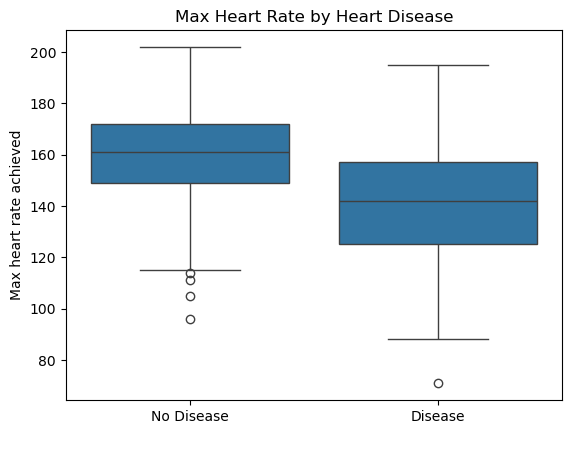

In [44]:
sns.boxplot(df, x = 'heart_disease', y = 'thalach')
plt.title('Max Heart Rate by Heart Disease')
plt.xticks([0,1], ['No Disease', 'Disease'])
plt.xlabel(' ')
plt.ylabel('Max heart rate achieved')
plt.show()

Max heart rate is completely unrelated to whether or not a patient has heart disease. This isn't even a case of the results might be different if cases were included who weren't experiening chest pain or suspected other heart trouble, I got a p-value of *one!*, 100% chance of occuring randomly. 

### Test 2) Average blood pressure One sample T-test
Is the average (systolic) blood pressure different from 120 mmHg?

In [4]:
#null Hypothesis: mean bp = 120 mmHg
mu0 = 120

#one sample T-test
t_stat, p_val = stats.ttest_1samp(df['trestbps'], mu0)

print(f'Single Sample T-Test Results: ')
print(f" t-statistic = {t_stat:.3f}")
print(f" p-value = {p_val:.4}\n")

if p_val < 0.05:
    print(f"Reject the null: The average resting blood pressure is {df['trestbps'].mean():.2f} and it sufficiently different from 120 mmHg.")
else: 
    print(f" Fail to reject the null: The average resting blood pressure is {df['trestbps'].mean():.2f} and it is not sufficiently different from 120 mmHg.")

Single Sample T-Test Results: 
 t-statistic = 11.345
 p-value = 5.183e-25

Reject the null: The average resting blood pressure is 131.69 and it sufficiently different from 120 mmHg.


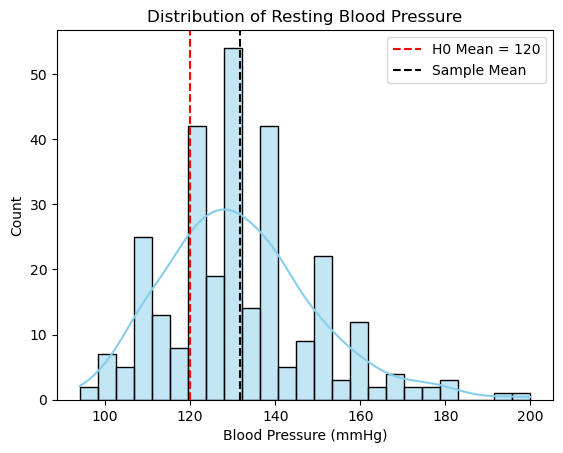

In [50]:
sns.histplot(df['trestbps'], bins=25, kde = True, color = 'skyblue')
plt.axvline(mu0, color='red', linestyle='--', label=f'H0 Mean = {mu0}')
plt.axvline(df['trestbps'].mean(), color='black', linestyle='--', label='Sample Mean')
plt.title('Distribution of Resting Blood Pressure')
plt.xlabel('Blood Pressure (mmHg)')
plt.ylabel('Count')
plt.legend()
plt.show()

My sample had an average blood pressure greater than what is considered the heathly or normal range. This sample is only of people who had were experiening heart issues, or had some reason to suspect something was wrong, so likely cannot be applied to the overall population of adults, but it does suggest that high blood pressure could be a symptom of heart disease. 

## Part 3)
For the Average blood pressure one sample T-test, a type I error would be rejecting the null that average (systolic) blood pressure is  120 mmHg, when the average was 120 mmHG.
A type II error would be failing to reject the null, when the average blood pressure was not 120 mmHG. 
In general, it is worse for patient care to tell patients they are fine when they are not. More tests can always be run if results are in doubt before starting treatment, but when results say a patient is fine it can be very hard to find treatment,  so false negatives are worse. 


## Part Four) Sample Size and Power Planning 
- Pick one of your tests.
- Assume α = 0.05 and desired power between 0.8–0.9.
- Estimate effect size from your data or justify a hypothetical one.
- Compute the required sample size.
- Optional: Generate a power curve showing power vs sample size for your chosen effect size.
- Write 2–3 sentences interpreting how sample size, effect size, and power interact.

Sample size for two - sample T-test: Maximum heart rate by heart disease 


In [10]:
#I coded all of this having Forgotten that the the difference of means was zero, so this test just gives an error

# heart rate by disease
rate_disease = df[df['heart_disease'] ==1]['thalach'] # just the heart rate column for disease yes
rate_no_disease = df[df['heart_disease'] ==1]['thalach'] # heart rate column for disease no
n1 = len(rate_disease)
n2 = len(rate_no_disease)

#Need Effect size, Alpha, and Power -- given alpha and desired power

# Effect Size == Choem's d : mean diff / pooled standard deviation
mean_diff = rate_disease.mean() - rate_no_disease.mean()
pooled_std = np.sqrt(((n1-1)*rate_disease.std()**2 +(n2-1)*rate_no_disease.std()**2)/(n1+n2+2))
effect_size = mean_diff / pooled_std

# Power Analysis 
alpha = 0.05
power = 0.85
analysis = TTestIndPower()
required_n =analysis.solve_power(effect_size = effect_size, alpha = alpha, power = power, alternative = 'two-sided')

print(f"Two Sample T-Test Sample Size Calculation:")
print(f"Mean Difference = {mean_diff:.2f}")
print(f"Effect size (Cohen's d) = {effect_size:.3f}")
print(f"Required Sample size per group = {np.ceil(required_n)}")


C:\Users\black\anaconda3\Lib\site-packages\statsmodels\stats\power.py:448: HypothesisTestWarning: Warning: Effect size of 0 detected
  warnings.warn('Warning: Effect size of 0 detected', HypothesisTestWarning)


ValueError: Cannot detect an effect-size of 0. Try changing your effect-size.

In [21]:
# doing part 4 again for Average blood pressure One sample T-test
mu0 = 120 
effect_size = (df['trestbps'].mean()-mu0) / df['trestbps'].std()  # standard test statistic - mu/ standard deviation
#effect_size = .4
alpha = 0.05 # given
power = 0.7 # given desired range

# Initialize power analysis object
analysis = TTestPower()
required_n = analysis.solve_power(effect_size = effect_size, alpha=alpha, power=power, alternative='larger')

print(f"One Sample T-Test Sample Size Calculation:")
print(f"Sample Mean = {df['trestbps'].mean():.2f}")
print(f"Effect size (Cohen's d) = {effect_size:.3f}")
print(f"Required Sample size per group = {np.ceil(required_n)}")


One Sample T-Test Sample Size Calculation:
Sample Mean = 131.69
Effect size (Cohen's d) = 0.658
Required Sample size per group = 13.0


As effect size increases, the required sample size decreases.  
As power increase, the required sample size also increase.
